# Marketing Mix Model
- Justin Wall, Senior Data Scientist, Arclight Cycling
## Questions to answer
1. Which channels drive revenue? Channel decomposition + ROAS posteriors
2. Are we overspending anywhere? Saturation curves per channel
3. Where should we shift $500K? Budget reallocation optimizer
4. How long does advertising stick? Adstock decay estimates
5. How confident should we be? Posterior credible intervals

### Data Description
- 156 weeks (3 years, 2022–2024), enough history for seasonality and trend
- 5 channels: paid search, social, email, display, TV
- Realistic spend patterns: TV is bursty/seasonal, paid search is always-on, email is low-cost high-frequency, display is moderate, social ramps up over time
- Ground truth baked in: the data-generating process is intentional so paid search is genuinely over-saturated, TV has long adstock decay, email has high ROAS but low ceiling, and social is the underinvested channel, which will make the budget optimizer recommendation interesting and defensible
- Confounders included: seasonality (cycling is Q1/Q2 heavy), a trend, and some noise

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# ── Time index ────────────────────────────────────────────────────────────────
n = 156  # 3 years of weekly data
dates = pd.date_range("2022-01-03", periods=n, freq="W-MON")
week_of_year = dates.isocalendar().week.to_numpy().astype(float)
year_idx = (dates.year - 2022).to_numpy().astype(float)  # 0, 1, 2

# ── Seasonality (cycling peaks Jan–Apr, secondary Oct) ────────────────────────
seasonality = (
    1.20 * np.sin(2 * np.pi * (week_of_year - 4) / 52)   # primary Jan/Feb peak
  + 0.25 * np.sin(4 * np.pi * (week_of_year - 4) / 52)   # secondary harmonic
)

# ── Long-run trend (modest 8% annual revenue growth) ─────────────────────────
trend = 0.0015 * np.arange(n)

# ── Spend patterns ────────────────────────────────────────────────────────────
# Paid search: always-on, gradually increasing, heavy Q1
paid_search = (
    18_000
    + 4_000 * year_idx
    + 6_000 * np.clip(np.sin(2 * np.pi * (week_of_year - 4) / 52), 0, None)
    + rng.normal(0, 1_500, n)
).clip(8_000)

# Social: low early, ramps significantly by year 3, spiky campaigns
social_base = 8_000 + 5_000 * year_idx
campaign_spikes = rng.choice([0, 1], size=n, p=[0.75, 0.25]) * rng.uniform(5_000, 15_000, n)
social = (social_base + campaign_spikes + rng.normal(0, 1_000, n)).clip(2_000)

# Email: low spend, consistent, slight Q1 push (cost = deployment + creative)
email = (
    2_500
    + 800 * np.clip(np.sin(2 * np.pi * (week_of_year - 6) / 52), 0, None)
    + rng.normal(0, 300, n)
).clip(1_000)

# Display: moderate, always-on retargeting, modest growth
display = (
    9_000
    + 1_500 * year_idx
    + rng.normal(0, 1_200, n)
).clip(4_000)

# TV: bursty — two flights per year (Q1 brand push + Q4 holiday), else zero
tv = np.zeros(n)
for yr in range(3):
    base_week = yr * 52
    # Q1 flight: weeks 2–8
    q1 = np.arange(base_week + 2, min(base_week + 9, n))
    tv[q1] = rng.uniform(60_000, 120_000, len(q1))
    # Q4 flight: weeks 40–47
    q4 = np.arange(base_week + 40, min(base_week + 48, n))
    tv[q4] = rng.uniform(50_000, 100_000, len(q4))

# ── Adstock transformations ───────────────────────────────────────────────────
def adstock(x, decay):
    """Geometric adstock — carryover effect of advertising."""
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = x[t] + decay * out[t - 1]
    return out

paid_search_adstocked = adstock(paid_search, decay=0.3)   # short memory
social_adstocked       = adstock(social,      decay=0.4)   # moderate
email_adstocked        = adstock(email,        decay=0.2)   # very short
display_adstocked      = adstock(display,      decay=0.35)  # moderate
tv_adstocked           = adstock(tv,           decay=0.7)   # long brand halo

# ── Hill (saturation) transformation ─────────────────────────────────────────
def hill(x, k, n_hill):
    """Hill function: diminishing returns. k = half-saturation point."""
    return x**n_hill / (k**n_hill + x**n_hill)

# Normalize each channel to [0, spend_scale] before Hill so k is interpretable
def hill_scaled(x, k_pct=0.6, n_hill=2.0):
    """k as percentile of observed spend, so saturation is data-relative."""
    k = np.percentile(x[x > 0], k_pct * 100)
    return hill(x, k, n_hill)

ps_sat   = hill_scaled(paid_search_adstocked, k_pct=0.45, n_hill=3.0)  # heavy saturation
soc_sat  = hill_scaled(social_adstocked,       k_pct=0.75, n_hill=1.8)  # under-saturated
em_sat   = hill_scaled(email_adstocked,         k_pct=0.55, n_hill=2.2)
disp_sat = hill_scaled(display_adstocked,       k_pct=0.60, n_hill=2.0)
tv_sat   = hill_scaled(tv_adstocked,            k_pct=0.65, n_hill=1.5)  # linear-ish (bursty)

# ── Revenue DGP ───────────────────────────────────────────────────────────────
# Coefficients represent max incremental revenue contribution (at full saturation)
# Paid search: high absolute but heavily saturated → low marginal ROAS
# Social: moderate spend but under-saturated → high marginal ROAS
# Email: tiny spend, great marginal ROAS, low ceiling
# TV: big brand halo, hard to attribute short-term
BASELINE = 280_000   # weekly baseline revenue (zero-marketing floor)

revenue = (
    BASELINE
    + 80_000  * ps_sat       # paid search — large coef but flattened
    + 70_000  * soc_sat      # social — meaningful, still on steep part of curve
    + 40_000  * em_sat       # email — punches above its weight
    + 35_000  * disp_sat     # display — supporting role
    + 90_000  * tv_sat       # TV — biggest max effect, long decay
    + 60_000  * seasonality  # seasonal swing
    + 15_000  * trend        # growth trend
    + rng.normal(0, 12_000, n)  # noise
)

# ── Assemble dataframe ────────────────────────────────────────────────────────
df = pd.DataFrame({
    "week":         dates,
    "revenue":      revenue.round(2),
    "spend_paid_search": paid_search.round(2),
    "spend_social":      social.round(2),
    "spend_email":       email.round(2),
    "spend_display":     display.round(2),
    "spend_tv":          tv.round(2),
})

df.to_csv("../data/arclight_mmm_data.csv", index=False)
print(df.describe().round(0).to_string())
print(f"\nTotal rows: {len(df)}")
print(f"Date range: {df.week.min().date()} → {df.week.max().date()}")
print(f"\nMean weekly revenue:     ${df.revenue.mean():,.0f}")
print(f"Mean weekly total spend: ${(df[['spend_paid_search','spend_social','spend_email','spend_display','spend_tv']].sum(axis=1).mean()):,.0f}")

                      week   revenue  spend_paid_search  spend_social  spend_email  spend_display  spend_tv
count                  156     156.0              156.0         156.0        156.0          156.0     156.0
mean   2023-06-29 12:00:00  415868.0            23819.0       15678.0       2731.0        10428.0   23666.0
min    2022-01-03 00:00:00  277597.0            15797.0        5927.0       1804.0         6856.0       0.0
25%    2022-10-01 06:00:00  366490.0            20607.0       11853.0       2402.0         9219.0       0.0
50%    2023-06-29 12:00:00  405294.0            23664.0       15312.0       2691.0        10492.0       0.0
75%    2024-03-26 18:00:00  463186.0            26642.0       18740.0       3049.0        11599.0   60899.0
max    2024-12-23 00:00:00  570690.0            34228.0       32077.0       3992.0        14472.0  116401.0
std                    NaN   62926.0             4170.0        6135.0        457.0         1645.0   38402.0

Total rows: 156
Date range:

## Step 1 -> Data Alignment
Align with key stakeholders on the base data before going further. Is what we see here what is expected from each channel? Meet with channel owners and learn about intricacies in the data, create an event log to help inform the eventual model. We will show them a few graphs up front: 1) Spend & Revenue over time, 2) Channel spend composition over time, 3) Any limitations or issues in the data

In [21]:
# ── Cell 1: Imports & Load ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

df = pd.read_csv("../data/arclight_mmm_data.csv", parse_dates=["week"])

CHANNELS = ["spend_paid_search", "spend_social", "spend_email", "spend_display", "spend_tv"]

LABELS   = ["Paid Search", "Social", "Email", "Display", "TV"]
COLORS   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

df["total_spend"] = df[CHANNELS].sum(axis=1)

print(f"Rows: {len(df)}  |  {df.week.min().date()} → {df.week.max().date()}")
df[["revenue", "total_spend"] + CHANNELS].describe().round(0)

Rows: 156  |  2022-01-03 → 2024-12-23


,revenue,total_spend,spend_paid_search,spend_social,spend_email,spend_display,spend_tv
count,156.0,156.0,156.0,156.0,156.0,156.0,156.0
mean,415868.0,76322.0,23819.0,15678.0,2731.0,10428.0,23666.0
std,62926.0,38318.0,4170.0,6135.0,457.0,1645.0,38402.0
min,277597.0,35362.0,15797.0,5927.0,1804.0,6856.0,0.0
25%,366490.0,48634.0,20607.0,11853.0,2402.0,9219.0,0.0
50%,405294.0,60042.0,23664.0,15312.0,2691.0,10492.0,0.0
75%,463186.0,111798.0,26642.0,18740.0,3049.0,11599.0,60899.0
max,570690.0,176053.0,34228.0,32077.0,3992.0,14472.0,116401.0


***
**Notes:** Weekly data from 1/3/2022 to 12/23/2024. Some 0's in TV.
***
***

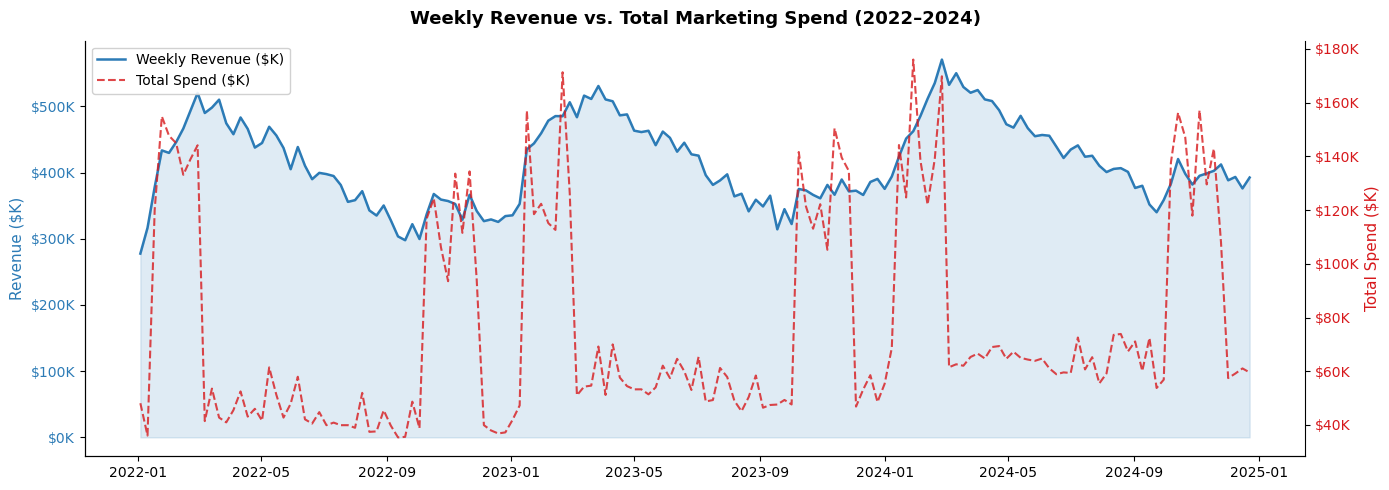

In [22]:
# ── Cell 2: Revenue & Total Spend Over Time ───────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(df.week, df.revenue / 1e3, alpha=0.15, color="#2c7bb6")
ax1.plot(df.week, df.revenue / 1e3, color="#2c7bb6", lw=1.8, label="Weekly Revenue ($K)")
ax1.set_ylabel("Revenue ($K)", color="#2c7bb6")
ax1.tick_params(axis="y", labelcolor="#2c7bb6")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

ax2 = ax1.twinx()
ax2.plot(df.week, df.total_spend / 1e3, color="#d7191c", lw=1.5,
         linestyle="--", alpha=0.8, label="Total Spend ($K)")
ax2.set_ylabel("Total Spend ($K)", color="#d7191c")
ax2.tick_params(axis="y", labelcolor="#d7191c")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax2.spines["right"].set_visible(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

ax1.set_title("Weekly Revenue vs. Total Marketing Spend (2022–2024)",
              fontweight="bold", pad=12)
ax1.set_xlabel("")
fig.tight_layout()
plt.savefig("01_revenue_vs_spend.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** Over the past 3 years we can see cyclical revenue spikes during spring time when bikes are being purchased for the summer, and small bumps of revenue in line with our ad spend, but we cannot discern causality with this chart. We have 2 periods of marketing spend each year, one around holiday, and one in early spring.
***
***

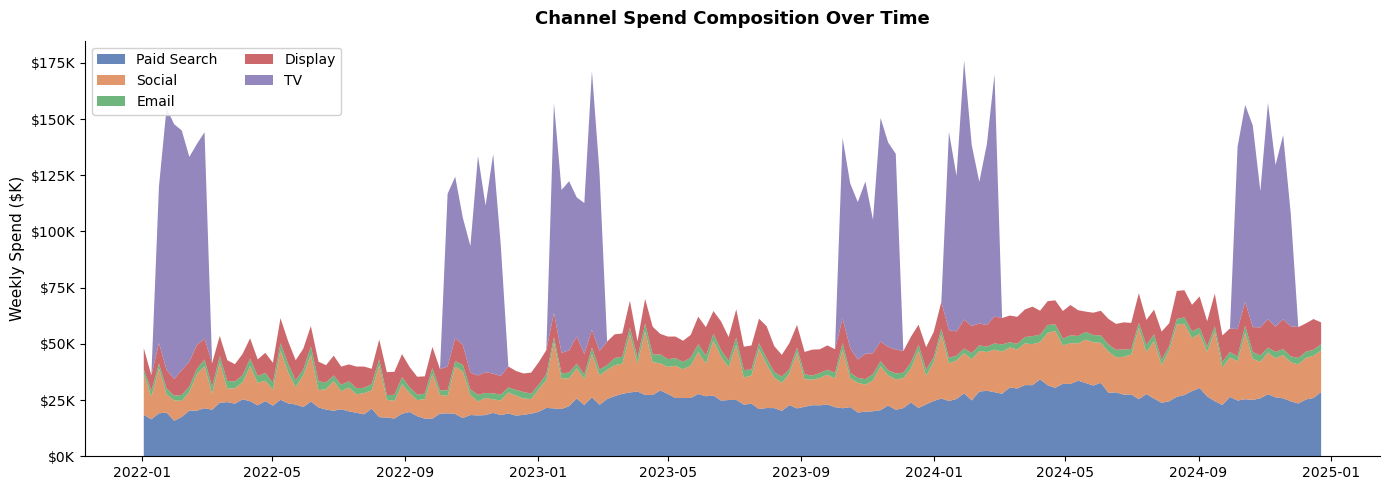

In [23]:
# ── Cell 3: Channel Spend Composition Over Time ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

spend_matrix = df[CHANNELS].values / 1e3
ax.stackplot(df.week, spend_matrix.T, labels=LABELS, colors=COLORS, alpha=0.85)

ax.set_title("Channel Spend Composition Over Time",
             fontweight="bold", pad=12)
ax.set_ylabel("Weekly Spend ($K)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.legend(loc="upper left", framealpha=0.9, ncol=2)
ax.set_xlabel("")
fig.tight_layout()
plt.savefig("02_channel_composition.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** The spikes are now clearly related to TV spend, whereas the other channels apperas to just have a general increasing trend with some slight hills throughout the years. Paid search is pretty consistent, as is email. Display & social have increased over the past 3 years.
***
***

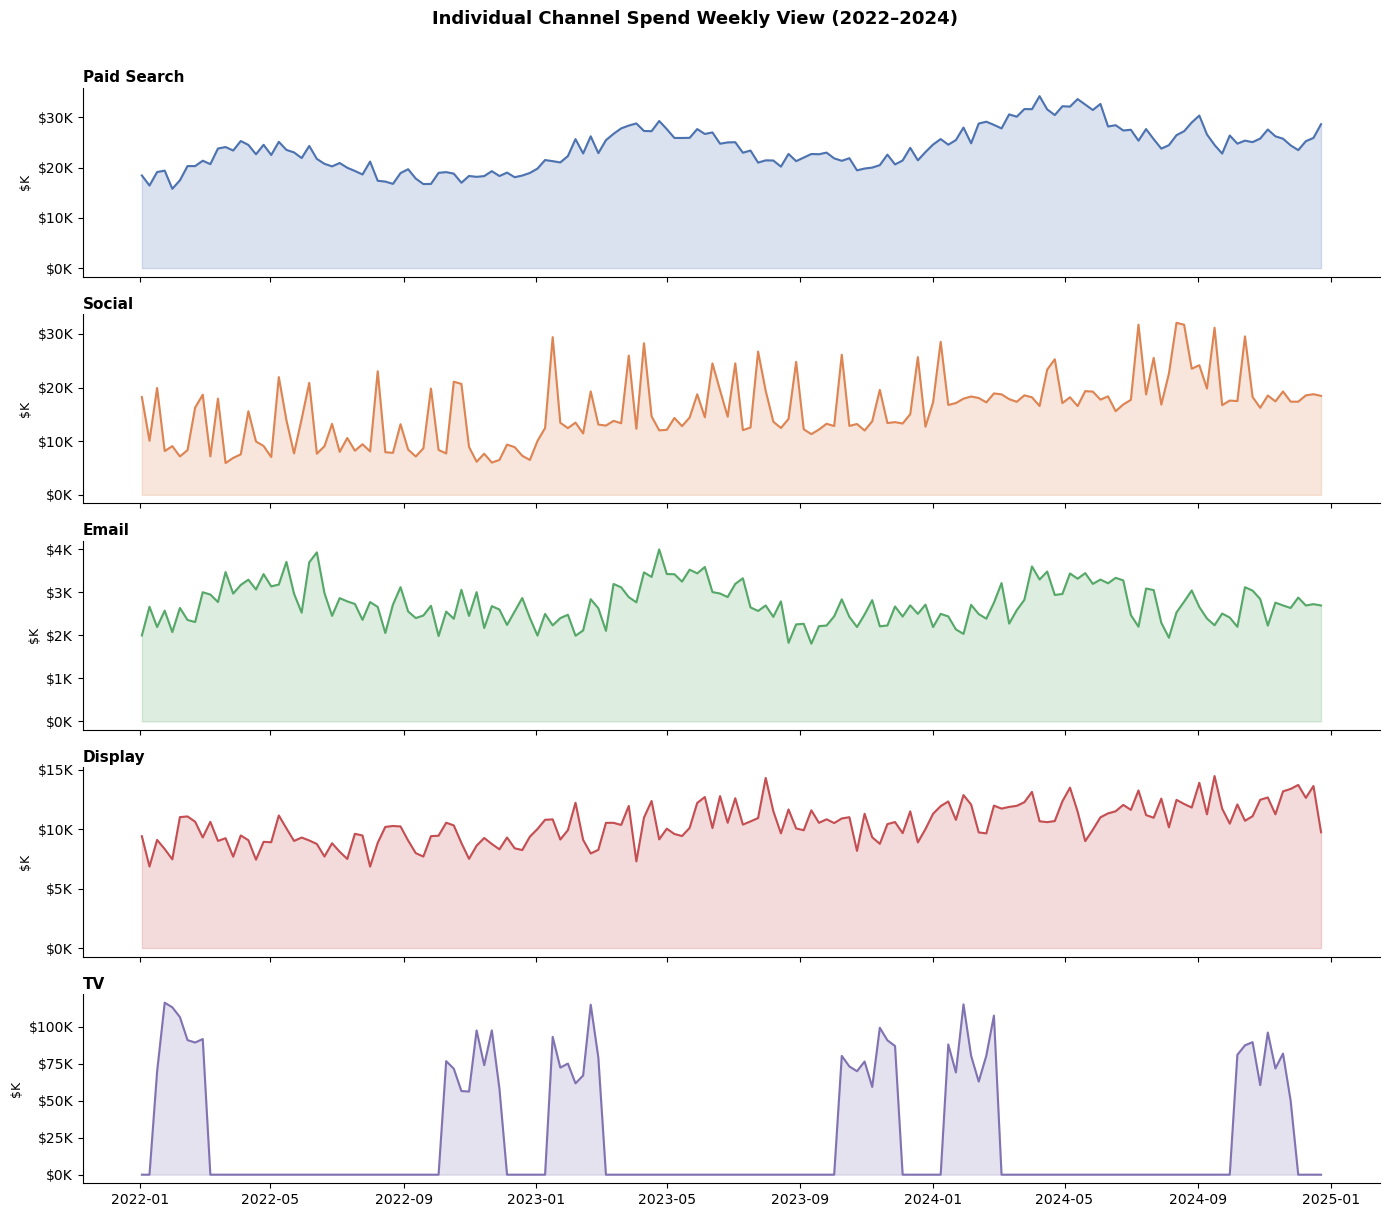

In [25]:
# ── Cell 4: Per-Channel Spend Over Time (Small Multiples) ─────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

for ax, col, label, color in zip(axes, CHANNELS, LABELS, COLORS):
    ax.fill_between(df.week, df[col] / 1e3, alpha=0.2, color=color)
    ax.plot(df.week, df[col] / 1e3, color=color, lw=1.5)
    ax.set_ylabel("$K", fontsize=9)
    ax.set_title(label, fontsize=11, fontweight="bold", loc="left", pad=4)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

axes[-1].set_xlabel("")
fig.suptitle("Individual Channel Spend Weekly View (2022–2024)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("03_channel_small_multiples.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** The seasonality and general increase of paid search is apparant here, as is teh general increase in social over time. Email appears flat to down, and display appears as an increase. TV has some large spikes over time and then completely drops to zero for long periods of time.
***
***

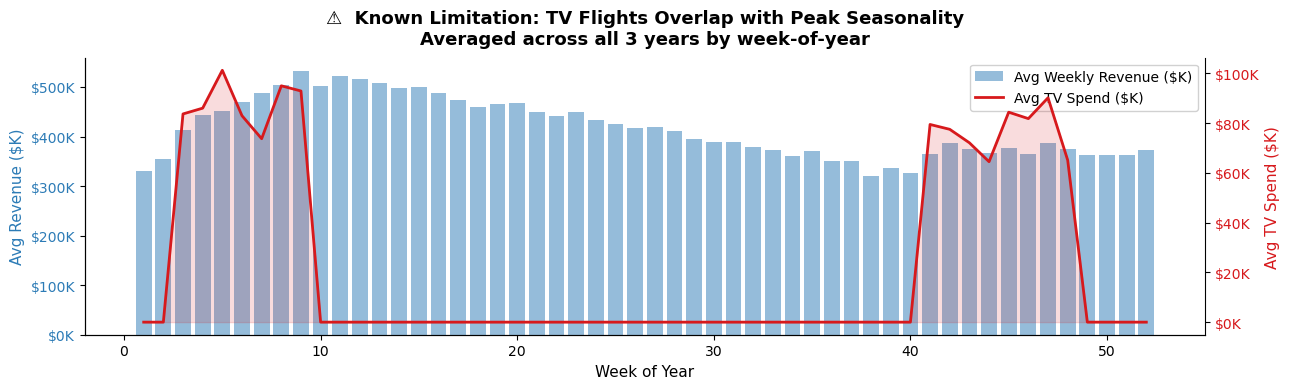


📋 Interpretation note for business team:
TV spend is concentrated in weeks 2–8 (Q1) and weeks 40–47 (Q4),
which happen to be Arclight's strongest revenue weeks regardless of advertising.
The model will need to carefully separate TV's causal effect from natural seasonality.


In [26]:
# ── Cell 5: Honest Limitation — TV vs Seasonality Overlap ─────────────────────
df["week_of_year"] = df.week.dt.isocalendar().week.astype(int)
avg_by_week = df.groupby("week_of_year")[["revenue", "spend_tv"]].mean()

fig, ax1 = plt.subplots(figsize=(13, 4))

ax1.bar(avg_by_week.index, avg_by_week.revenue / 1e3,
        color="#2c7bb6", alpha=0.5, label="Avg Weekly Revenue ($K)")
ax1.set_ylabel("Avg Revenue ($K)", color="#2c7bb6")
ax1.tick_params(axis="y", labelcolor="#2c7bb6")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

ax2 = ax1.twinx()
ax2.plot(avg_by_week.index, avg_by_week.spend_tv / 1e3,
         color="#d7191c", lw=2, label="Avg TV Spend ($K)")
ax2.fill_between(avg_by_week.index, avg_by_week.spend_tv / 1e3,
                 alpha=0.15, color="#d7191c")
ax2.set_ylabel("Avg TV Spend ($K)", color="#d7191c")
ax2.tick_params(axis="y", labelcolor="#d7191c")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax2.spines["right"].set_visible(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", framealpha=0.9)

ax1.set_title(
    "⚠️  Known Limitation: TV Flights Overlap with Peak Seasonality\n"
    "Averaged across all 3 years by week-of-year",
    fontweight="bold", pad=10
)
ax1.set_xlabel("Week of Year")
fig.tight_layout()
plt.savefig("04_tv_seasonality_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📋 Interpretation note for business team:")
print("TV spend is concentrated in weeks 2–8 (Q1) and weeks 40–47 (Q4),")
print("which happen to be Arclight's strongest revenue weeks regardless of advertising.")
print("The model will need to carefully separate TV's causal effect from natural seasonality.")

***
**Notes:** TV spikes are correlated with seasonality. We do TV ads when we know our business is going to ramp up.
***
***

## Step 2 -> Explore Data

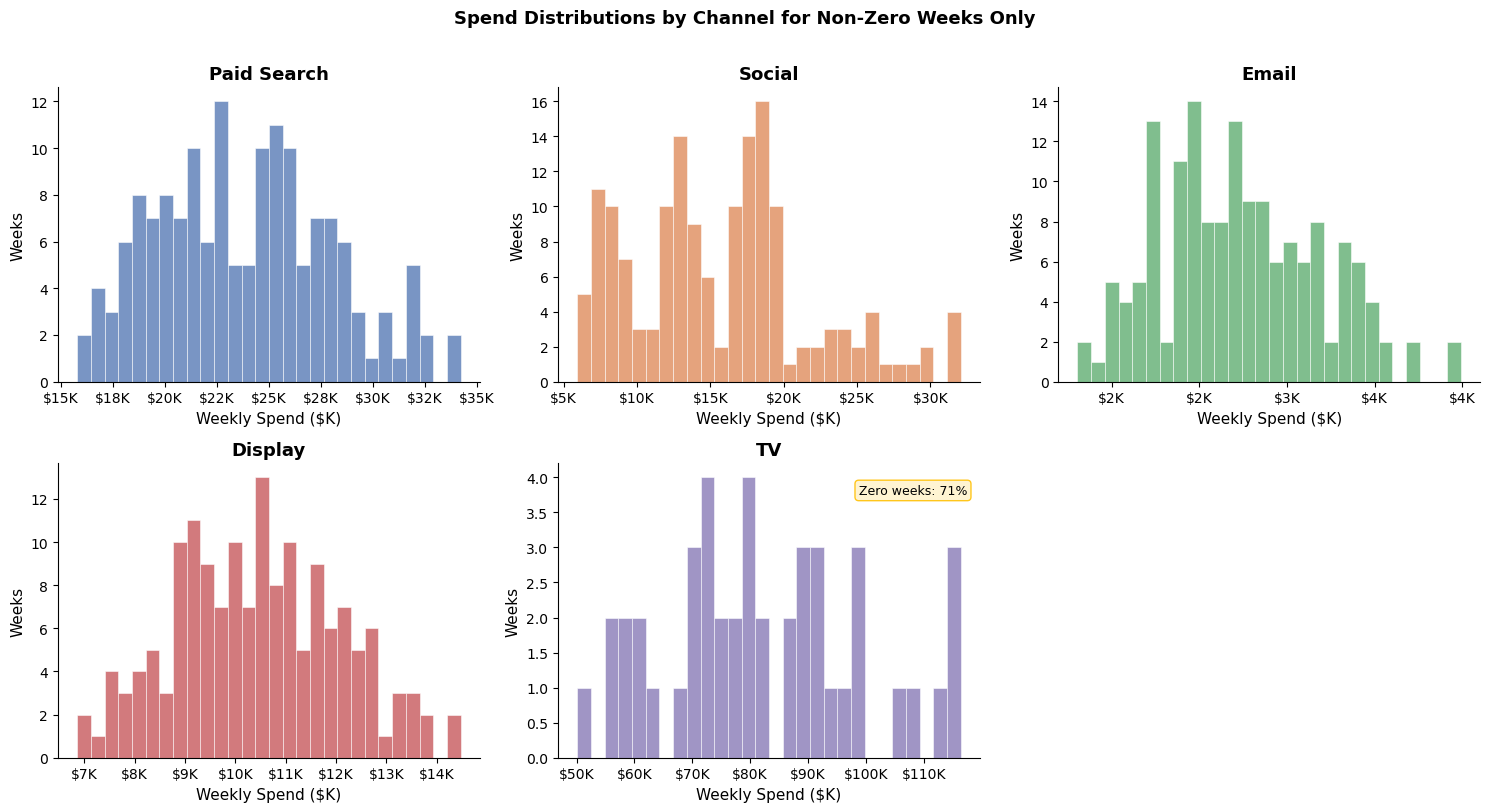

Zero-spend weeks per channel:
  Paid Search      0 of 156 weeks (0%)
  Social           0 of 156 weeks (0%)
  Email            0 of 156 weeks (0%)
  Display          0 of 156 weeks (0%)
  TV             111 of 156 weeks (71%)


In [27]:
# ── Cell 6: Spend Distributions per Channel ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col, label, color in zip(axes, CHANNELS, LABELS, COLORS):
    nonzero = df[col][df[col] > 0]
    ax.hist(nonzero / 1e3, bins=28, color=color, alpha=0.75, edgecolor="white", lw=0.5)
    zero_pct = (df[col] == 0).mean() * 100
    ax.set_title(f"{label}", fontweight="bold")
    ax.set_xlabel("Weekly Spend ($K)")
    ax.set_ylabel("Weeks")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    note = f"Zero weeks: {zero_pct:.0f}%" if zero_pct > 0 else ""
    if note:
        ax.text(0.97, 0.93, note, transform=ax.transAxes,
                ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="#fff3cd", ec="#ffc107", alpha=0.9))

# hide unused 6th panel
axes[5].set_visible(False)
fig.suptitle("Spend Distributions by Channel for Non-Zero Weeks Only",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("05_spend_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Print zero-week summary
print("Zero-spend weeks per channel:")
for col, label in zip(CHANNELS, LABELS):
    z = (df[col] == 0).sum()
    print(f"  {label:<14} {z:>3} of {len(df)} weeks ({z/len(df)*100:.0f}%)")

***
**Notes:** Most weeks we spent $0 on TV. Display, search, and email look normally distributed, with email having the lowest variance.
***
***

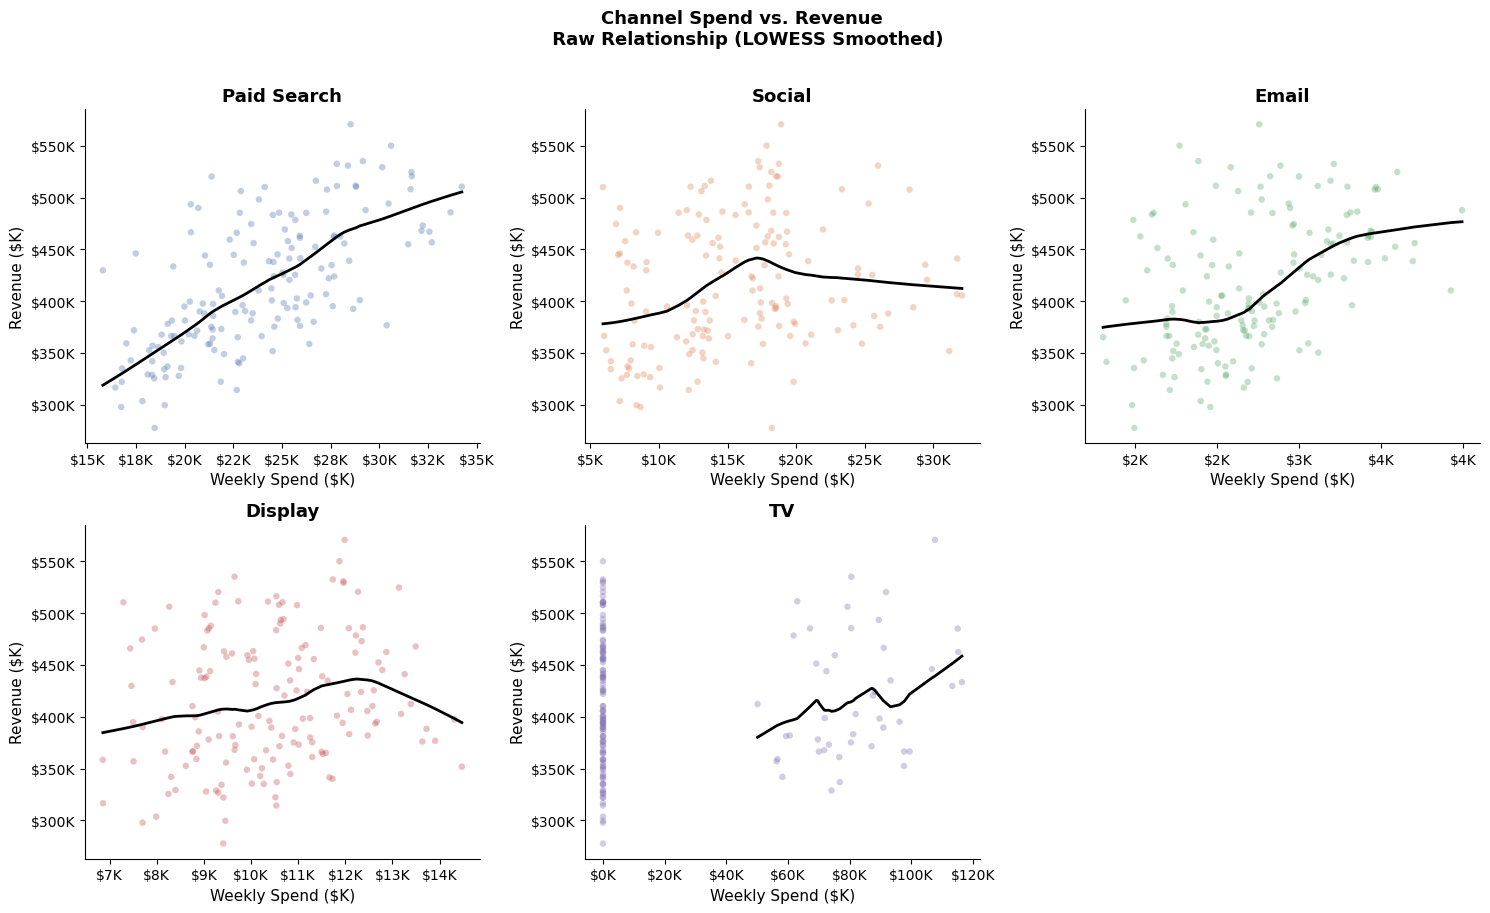

In [29]:
# ── Cell 7: Spend vs. Revenue Scatters (LOWESS) ───────────────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col, label, color in zip(axes, CHANNELS, LABELS, COLORS):
    x = df[col].values / 1e3
    y = df.revenue.values / 1e3
    ax.scatter(x, y, color=color, alpha=0.35, s=22, edgecolors="none")
    # LOWESS only on non-zero spend weeks
    mask = x > 0
    if mask.sum() > 10:
        smoothed = lowess(y[mask], x[mask], frac=0.5, return_sorted=True)
        ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", lw=2, label="LOWESS")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Weekly Spend ($K)")
    ax.set_ylabel("Revenue ($K)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

axes[5].set_visible(False)
fig.suptitle("Channel Spend vs. Revenue \n Raw Relationship (LOWESS Smoothed)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("06_spend_vs_revenue_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

***
Notes: Paid search appears linear, social flattens at a certain spot, email increases and then flattens, display decreases at a certain spot, tv seems noisy.
***
***

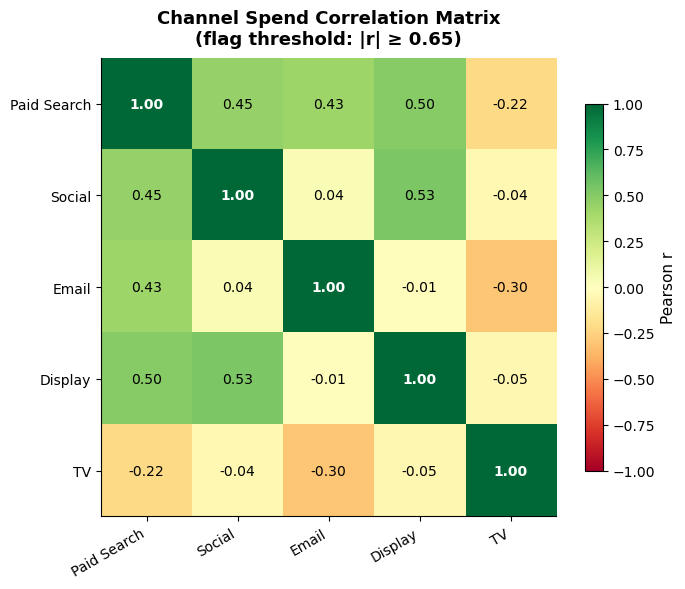

✅ No pairs above correlation threshold.


In [30]:

# ── Cell 8: Correlation Heatmap (Spend Channels Only) ─────────────────────────
spend_df = df[CHANNELS].copy()
spend_df.columns = LABELS
corr = spend_df.corr()

# Flag pairs above threshold
threshold = 0.65
flagged = []
for i in range(len(LABELS)):
    for j in range(i+1, len(LABELS)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            flagged.append((LABELS[i], LABELS[j], val))

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only — avoid redundancy
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        val = corr.iloc[i, j]
        txt_color = "black" if abs(val) < 0.75 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, color=txt_color, fontweight="bold" if abs(val) >= threshold else "normal")

ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=30, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_title("Channel Spend Correlation Matrix\n(flag threshold: |r| ≥ 0.65)",
             fontweight="bold", pad=10)
fig.tight_layout()
plt.savefig("07_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

if flagged:
    print("⚠️  Flagged pairs (|r| ≥ 0.65):")
    for a, b, v in flagged:
        print(f"  {a} ↔ {b}: r = {v:.2f}")
else:
    print("✅ No pairs above correlation threshold.")

***
**Notes:** I don't see anything concerning here, Paid search seems to get funding when everything else does, otherwise no concerning signals here.
***
***

Variance Inflation Factors:
    Channel      VIF Flag
Paid Search 1.923932 ✅ OK
     Social 1.491821 ✅ OK
      Email 1.411604 ✅ OK
    Display 1.656900 ✅ OK
         TV 1.112699 ✅ OK


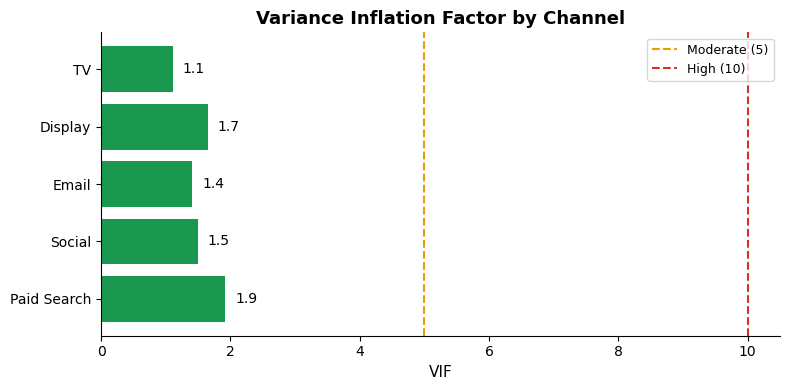

In [31]:

# ── Cell 9: VIF Table ─────────────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df[CHANNELS].values)
vif_data = pd.DataFrame({
    "Channel": ["const"] + LABELS,
    "VIF": [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
}).iloc[1:]  # drop intercept row

vif_data["Flag"] = vif_data["VIF"].apply(
    lambda v: "🔴 High — unstable coefficient" if v >= 10
    else ("🟡 Moderate — monitor" if v >= 5 else "✅ OK")
)

print("Variance Inflation Factors:")
print(vif_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(vif_data["Channel"], vif_data["VIF"],
               color=["#d73027" if v >= 10 else "#fee08b" if v >= 5 else "#1a9850"
                      for v in vif_data["VIF"]])
ax.axvline(5,  color="#e69f00", lw=1.5, linestyle="--", label="Moderate (5)")
ax.axvline(10, color="#d73027", lw=1.5, linestyle="--", label="High (10)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor by Channel", fontweight="bold")
ax.legend(fontsize=9)
for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=10)
fig.tight_layout()
plt.savefig("08_vif.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** Paid search is close to having a 2 for VIF, which would be an indicator it is related to some other features, but they're all safely uncorrelated.
***
***

Naive baseline R²  : 0.869
Implied zero-mktg baseline: $380.5K / week
Residual std dev   : $22.8K / week


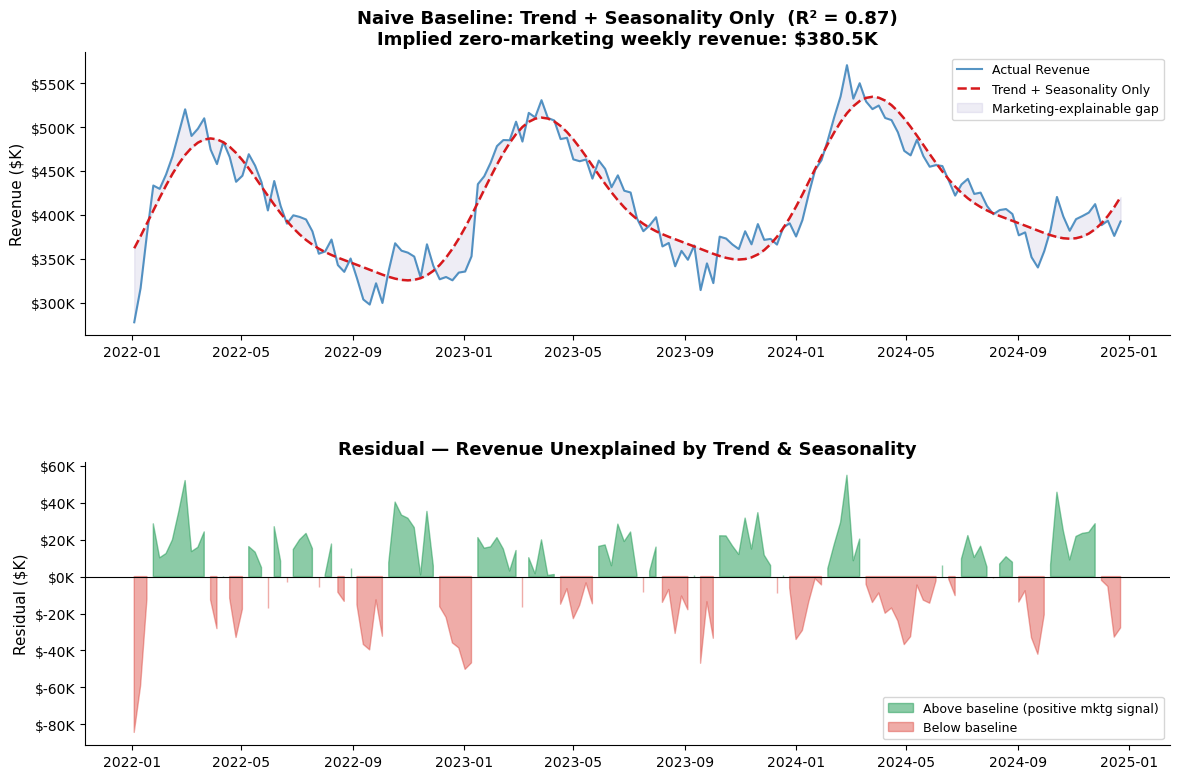


Revenue attribution (rough, pre-model):
  Baseline (trend + seasonality): ~98%
  Potentially marketing-driven:   ~2%
  ⚠️  Note: marketing likely contributes to the trend itself;
      this split understates marketing impact. Full MMM will untangle this.


In [10]:

# ── Cell 10: Naive Baseline Decomposition ─────────────────────────────────────
import statsmodels.api as sm

# Fourier terms to capture seasonality (K=2 harmonics ~ annual cycle)
t = np.arange(len(df))
K = 2
fourier = {}
for k in range(1, K + 1):
    fourier[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
    fourier[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)

baseline_df = pd.DataFrame(fourier)
baseline_df["trend"] = t / len(df)  # normalized 0→1
X_base = sm.add_constant(baseline_df)
model_base = sm.OLS(df.revenue, X_base).fit()

df["baseline_fitted"] = model_base.fittedvalues
df["baseline_residual"] = model_base.resid

r2 = model_base.rsquared
intercept_k = model_base.params["const"] / 1e3

print(f"Naive baseline R²  : {r2:.3f}")
print(f"Implied zero-mktg baseline: ${intercept_k:,.1f}K / week")
print(f"Residual std dev   : ${df.baseline_residual.std()/1e3:,.1f}K / week")

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 1, figure=fig, hspace=0.45)

# Top: actual vs fitted baseline
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.week, df.revenue / 1e3, color="#2c7bb6", lw=1.5, alpha=0.8, label="Actual Revenue")
ax1.plot(df.week, df.baseline_fitted / 1e3, color="#d7191c", lw=1.8,
         linestyle="--", label="Trend + Seasonality Only")
ax1.fill_between(df.week, df.baseline_fitted / 1e3, df.revenue / 1e3,
                 alpha=0.12, color="#756bb1", label="Marketing-explainable gap")
ax1.set_ylabel("Revenue ($K)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax1.set_title(f"Naive Baseline: Trend + Seasonality Only  (R² = {r2:.2f})\n"
              f"Implied zero-marketing weekly revenue: ${intercept_k:,.1f}K",
              fontweight="bold")
ax1.legend(fontsize=9)

# Bottom: residual — "marketing signal"
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(df.week, df.baseline_residual / 1e3, 0,
                 where=df.baseline_residual >= 0, color="#1a9850", alpha=0.5,
                 label="Above baseline (positive mktg signal)")
ax2.fill_between(df.week, df.baseline_residual / 1e3, 0,
                 where=df.baseline_residual < 0, color="#d73027", alpha=0.4,
                 label="Below baseline")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Residual ($K)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax2.set_title("Residual — Revenue Unexplained by Trend & Seasonality",
              fontweight="bold")
ax2.legend(fontsize=9)

plt.savefig("09_naive_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# Revenue split summary
mktg_share = (df.baseline_residual.clip(lower=0).sum() / df.revenue.sum()) * 100
baseline_share = 100 - mktg_share
print(f"\nRevenue attribution (rough, pre-model):")
print(f"  Baseline (trend + seasonality): ~{baseline_share:.0f}%")
print(f"  Potentially marketing-driven:   ~{mktg_share:.0f}%")
print("  ⚠️  Note: marketing likely contributes to the trend itself;")
print("      this split understates marketing impact. Full MMM will untangle this.")

***
**Notes:** We are seeing 87% of variance explained by trend & seasonality, meaning 13% of revenue is explained by marketing spend. That's already quite a bit of the revenue being explained by the strong cycling seasonality & business growth. We would bring in $380k with no marketing spend; that's purely organic search, word of mouth, brand equity, and repeat customers. The 98%/2% is misleading as marketing is built into our trend already, it's impossible to pull that out since it's helped develop all those non-paid marketing aspects above.
***
***

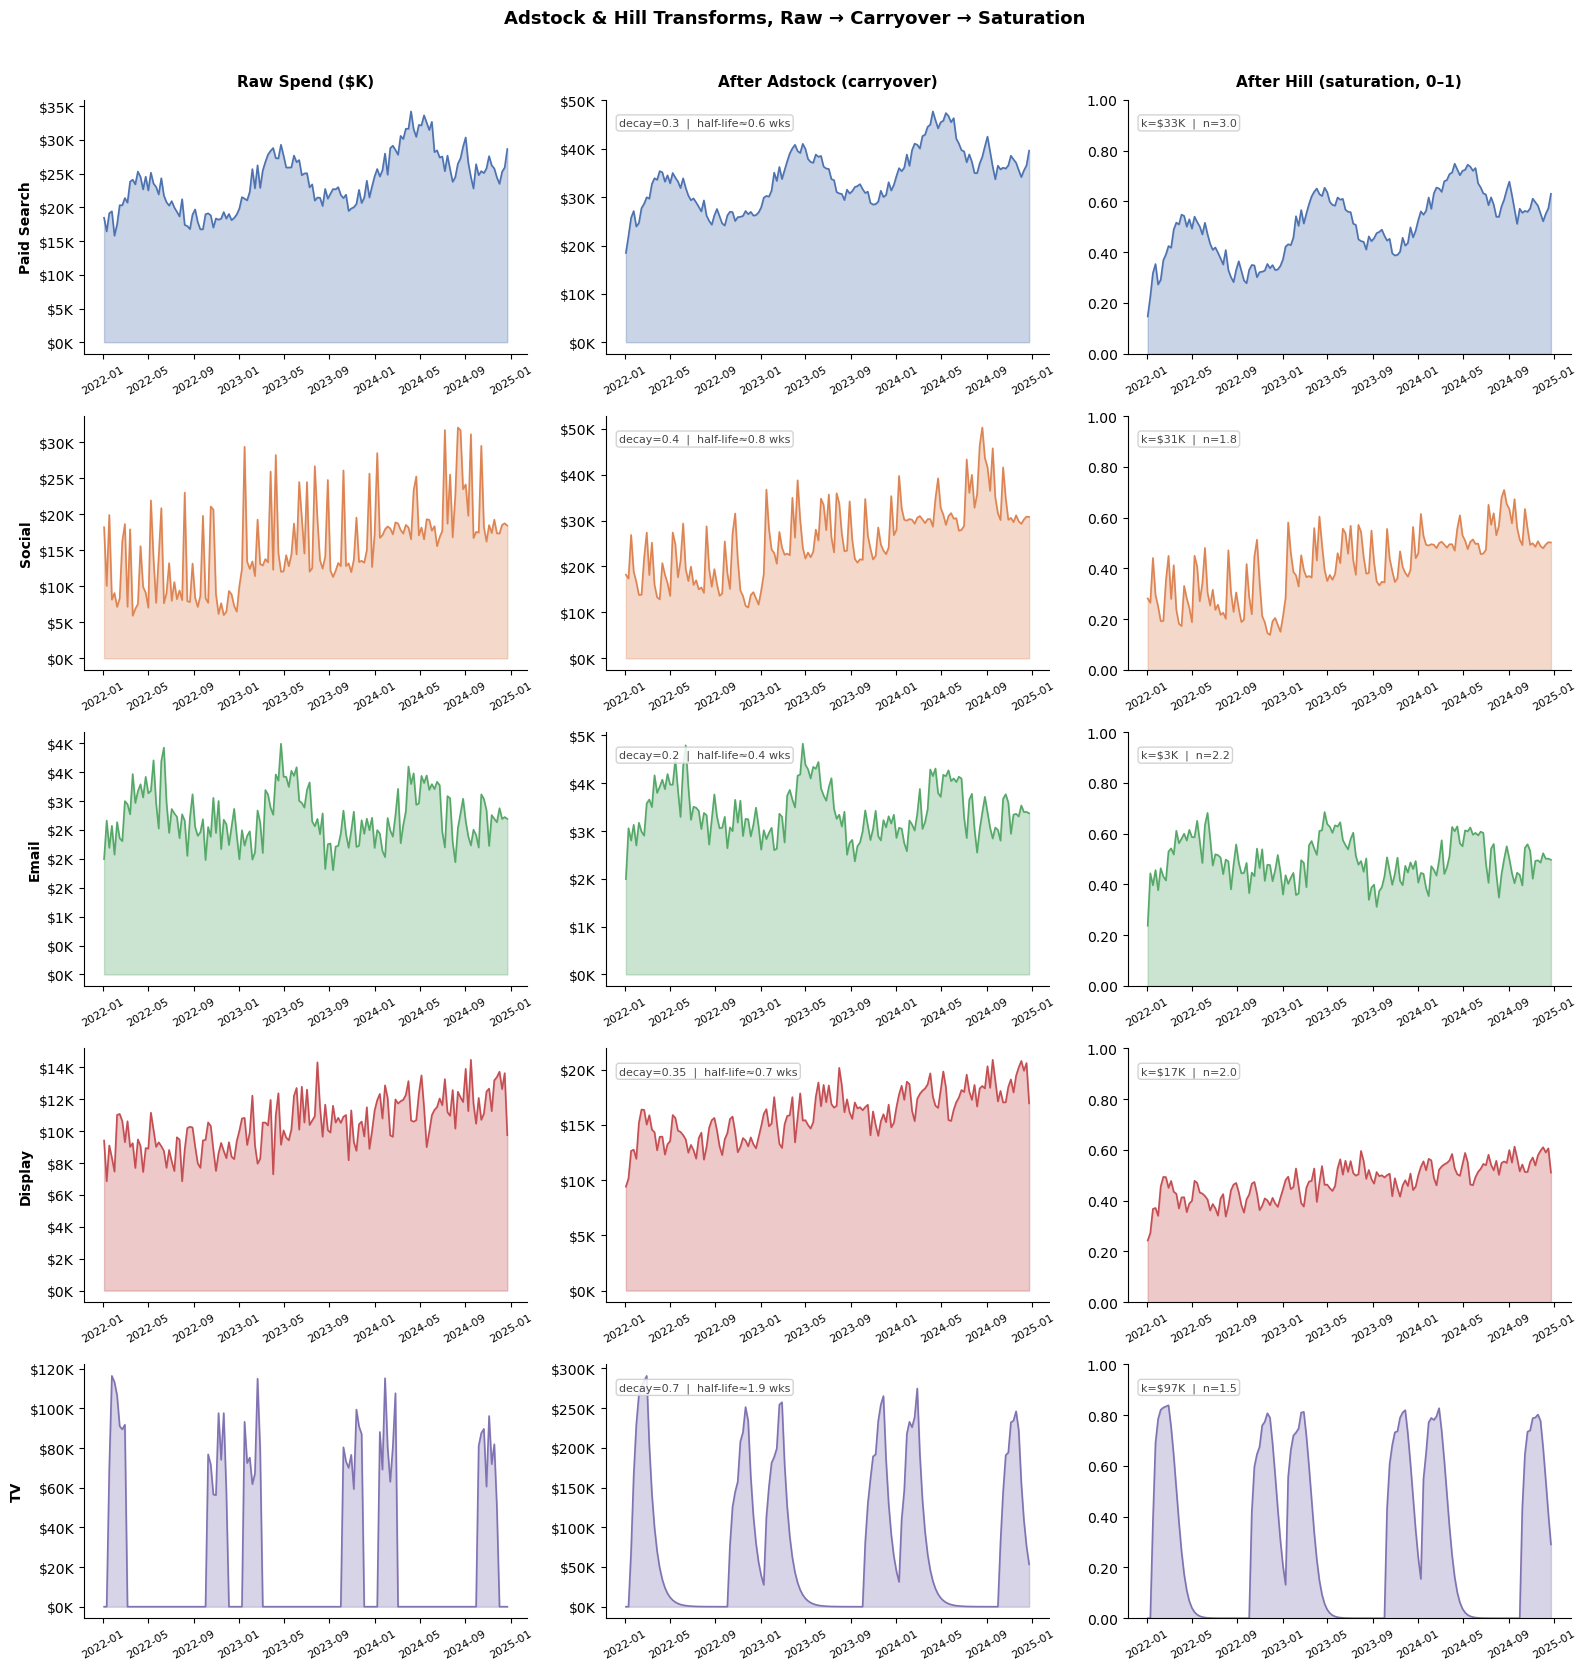

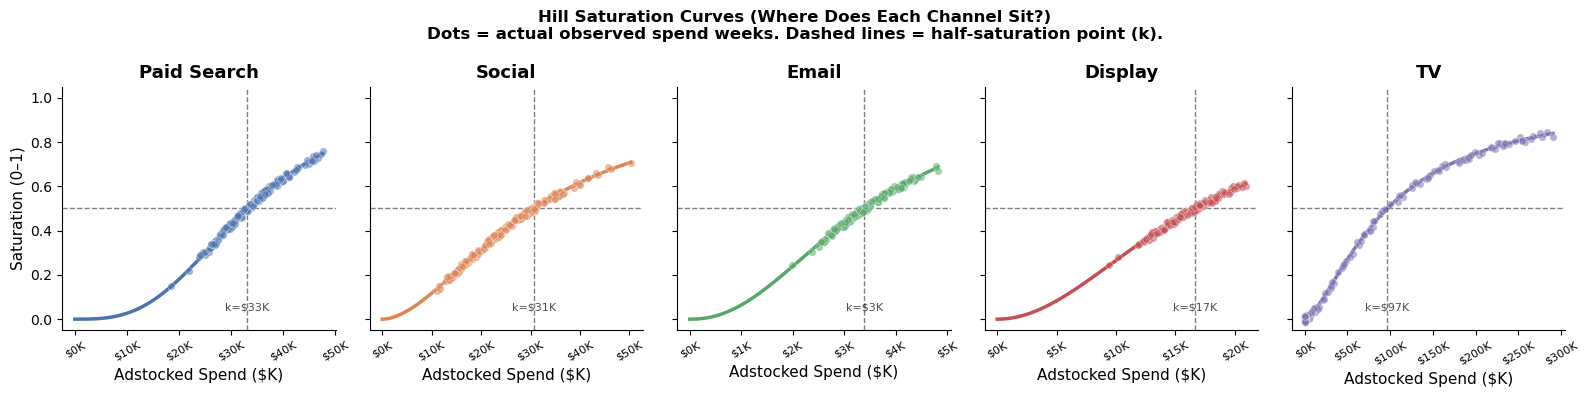

In [32]:
# ── Cell 11: Adstock & Hill — Hand-Rolled Transforms ─────────────────────────

def geometric_adstock(x: np.ndarray, decay: float) -> np.ndarray:
    out = np.empty_like(x, dtype=float)
    out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = x[t] + decay * out[t - 1]
    return out

def hill(x: np.ndarray, k: float, n: float) -> np.ndarray:
    return x**n / (k**n + x**n)

transform_params = {
    "spend_paid_search": dict(decay=0.30, k_pct=0.45, n=3.0),
    "spend_social":      dict(decay=0.40, k_pct=0.75, n=1.8),
    "spend_email":       dict(decay=0.20, k_pct=0.55, n=2.2),
    "spend_display":     dict(decay=0.35, k_pct=0.60, n=2.0),
    "spend_tv":          dict(decay=0.70, k_pct=0.65, n=1.5),
}

transformed = {}
for col, p in transform_params.items():
    x = df[col].values.astype(float)
    x_ads = geometric_adstock(x, p["decay"])
    nonzero = x_ads[x_ads > 0]
    k = np.percentile(nonzero, p["k_pct"] * 100)
    x_hill = hill(x_ads, k=k, n=p["n"])
    hl = np.log(0.5) / np.log(p["decay"])
    transformed[col] = dict(raw=x, adstocked=x_ads, saturated=x_hill,
                            k=k, half_life=hl, **p)

# -- 5x3 grid -----------------------------------------------------------------
fig, axes = plt.subplots(5, 3, figsize=(16, 17))  # taller figure
col_titles = ["Raw Spend ($K)", "After Adstock (carryover)", "After Hill (saturation, 0–1)"]

for row, (col, label, color) in enumerate(zip(CHANNELS, LABELS, COLORS)):
    p = transformed[col]

    # raw
    axes[row, 0].fill_between(df.week, p["raw"] / 1e3, alpha=0.3, color=color)
    axes[row, 0].plot(df.week, p["raw"] / 1e3, color=color, lw=1.2)
    axes[row, 0].set_ylabel(label, fontweight="bold", fontsize=10)
    axes[row, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

    # adstocked — subtitle above the axes, not inside it
    axes[row, 1].fill_between(df.week, p["adstocked"] / 1e3, alpha=0.3, color=color)
    axes[row, 1].plot(df.week, p["adstocked"] / 1e3, color=color, lw=1.2)
    axes[row, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

    # hill
    axes[row, 2].fill_between(df.week, p["saturated"], alpha=0.3, color=color)
    axes[row, 2].plot(df.week, p["saturated"], color=color, lw=1.2)
    axes[row, 2].set_ylim(0, 1)
    axes[row, 2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))

    # rotate x-tick labels on all panels in this row
    for c in range(3):
        axes[row, c].tick_params(axis="x", rotation=30, labelsize=8)

    # param annotations as text inside the plot (avoids title overlap)
    axes[row, 1].text(0.03, 0.93,
        f"decay={p['decay']}  |  half-life≈{p['half_life']:.1f} wks",
        transform=axes[row, 1].transAxes,
        fontsize=8, color="#444", va="top",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#ccc", alpha=0.85))

    axes[row, 2].text(0.03, 0.93,
        f"k=${p['k']/1e3:,.0f}K  |  n={p['n']}",
        transform=axes[row, 2].transAxes,
        fontsize=8, color="#444", va="top",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#ccc", alpha=0.85))

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)

fig.suptitle("Adstock & Hill Transforms, Raw → Carryover → Saturation",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("10_transforms.png", dpi=150, bbox_inches="tight")
plt.show()

# -- Saturation curves (replace existing block) -------------------------------
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

rng_jitter = np.random.default_rng(0)

for ax, col, label, color in zip(axes, CHANNELS, LABELS, COLORS):
    p = transformed[col]
    x_range = np.linspace(0, p["adstocked"].max(), 300)
    y_range = hill(x_range, k=p["k"], n=p["n"])

    # smooth curve
    ax.plot(x_range / 1e3, y_range, color=color, lw=2.5, zorder=2)

    # reference lines
    ax.axvline(p["k"] / 1e3, color="black", lw=1, linestyle="--", alpha=0.5)
    ax.axhline(0.5,           color="black", lw=1, linestyle="--", alpha=0.5)

    # actual spend dots — larger, more opaque, with vertical jitter so they
    # sit visibly above/below the curve rather than fusing with it
    y_dots = hill(p["adstocked"], p["k"], p["n"])
    jitter = rng_jitter.uniform(-0.015, 0.015, size=len(y_dots))
    ax.scatter(
        p["adstocked"] / 1e3,
        y_dots + jitter,
        color=color,
        alpha=0.55,
        s=28,
        edgecolors="white",
        linewidths=0.4,
        zorder=3,
    )

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Adstocked Spend ($K)")
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    ax.text(p["k"] / 1e3, 0.04, f"k=${p['k']/1e3:,.0f}K",
            fontsize=8, ha="center", color="black", alpha=0.7)

axes[0].set_ylabel("Saturation (0–1)")
fig.suptitle("Hill Saturation Curves (Where Does Each Channel Sit?)\n"
             "Dots = actual observed spend weeks. Dashed lines = half-saturation point (k).",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("11_saturation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** There are two misconceptions when putting advertising spend into a linear regression:

1) every dollar has the same effect no matter how much you are spending in that channel,
2) advertising dollars are only useful in the week they are spent.

- Adstock is the idea that advertising spend builds & decays over time. Adstock wouldn't be as useful in a marketing effort that shows instant attribution, such as a promo email where customers will click & puchase within a day. For adstock we just need to pick out a decay value to determine how quickly the advertising effect decays after the spend.
- The hill function models diminishing returns, it's used instead of log or sqrt because of the explicit half satruation parameter that is directly interpretable, e.g. paid search saturates around $25k/week. This value is interpretable as well. If the channel has very little spend variation, then don't use the hill function. In this dataset, email has low variation and low spend, so we may use a linear relationship with a skeptical prior. We always start by visualizing these so we can check the decay & shape parameters by eye before they go into the model where they are harder to see.

TLDR: Adstock or carryover is how media spend decays over time (lagged effects) whereas the hill function shows diminishing returns of each marketing dollar (saturation).

In the top graphic, the first box is raw spend, the second box is adstock where the dropoffs after each spend spike are smoothed out. The third box is for hill, where everything is compressed between 0 and 1, showing how much the channel is saturated instead of a dollar amount.

Business Explanation: For adstock, we know that advertising has effects beyond the initial exposure. We are using industry benchmarks to guess as how long it takes these effects to decay as a starting point, but will model them shortly. For hill, we know each additional dollar has a marginally smaller effect on revenue. The saturation curve shows when you're spending money to buy the same high-intent customer repeatedly. If you look at the saturation curve for paid search, you can see the dots are clustered on the flat part of the curve, menaing we may be over invested in this area.
***
***

## Step 3 -> Modeling

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pymc as pm
from pymc_marketing.mmm import MMM, GeometricAdstock, HillSaturation
import arviz as az

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
})

df = pd.read_csv("../data/arclight_mmm_data.csv", parse_dates=["week"])

CHANNELS = ["spend_paid_search", "spend_social", "spend_email", "spend_display", "spend_tv"]
LABELS   = ["Paid Search", "Social", "Email", "Display", "TV"]

# No manual Fourier — pymc-marketing handles this via yearly_seasonality
print(f"Loaded {len(df)} weeks  |  {df.week.min().date()} → {df.week.max().date()}")

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Loaded 156 weeks  |  2022-01-03 → 2024-12-23


***
**Notes:** Time for actual modeling, we'll reload our data and import our channels as a list. We will be using PYMC Marketing for this initiative.
***
***

In [2]:
# ── Cell 2: Prior Documentation ───────────────────────────────────────────────
#
# Priors are informed by three sources:
#   1. Industry knowledge (channel type → expected decay range)
#   2. EDA scatter plots (LOWESS shape → saturation expectation)
#   3. Transform cell (Cell 11) — empirical k values from adstocked spend
#
# We use weakly informative priors: centered on our best guess,
# wide enough that the data can move them substantially.
#
# Adstock decay → Beta(alpha, beta) — naturally bounded [0,1]
#   Beta mean = alpha / (alpha + beta)
#   We use concentration ~4 so the prior is soft, not dogmatic.
#
# Channel β coefficients → HalfNormal(sigma)
#   sigma set so ~95% of prior mass is below a plausible max weekly contribution.
#   TV and Paid Search have higher ceilings; Email has a low ceiling.
#
# Hill k → HalfNormal centered on empirical k from Cell 11 (in $K units)
# Hill n → HalfNormal(sigma=2), centered near 1, can reach 4+

prior_doc = {
    # channel         decay_mean   decay_conc   beta_sigma($K)  k_center($K)  n_sigma
    "Paid Search":  dict(decay=0.30, conc=4,  beta_s=60,  k=18,  n_s=1.5),
    "Social":       dict(decay=0.40, conc=4,  beta_s=55,  k=35,  n_s=2.0),
    "Email":        dict(decay=0.20, conc=4,  beta_s=30,  k=5,   n_s=1.5),
    "Display":      dict(decay=0.35, conc=4,  beta_s=40,  k=22,  n_s=1.5),
    "TV":           dict(decay=0.70, conc=4,  beta_s=80,  k=55,  n_s=2.0),
}

print("Prior centers by channel:")
print(f"{'Channel':<14} {'Decay':>6} {'β sigma':>9} {'k center':>10} {'n sigma':>8}")
print("-" * 52)
for ch, p in prior_doc.items():
    print(f"{ch:<14} {p['decay']:>6.2f} "
          f"${p['beta_s']:>7,}K "
          f"${p['k']:>8,}K "
          f"{p['n_s']:>8.1f}")

print("""
Reasoning summary:
  Paid Search : Low decay (search intent is immediate). Low k (saturates early
                per LOWESS). High n (sharp diminishing returns seen in scatter).
  Social      : Moderate decay (some awareness carryover). High k (under-
                saturated — dots cluster on steep part of curve in Cell 11).
  Email       : Very low decay (open-or-don't within 48hrs). Low beta ceiling
                (low spend channel, low absolute revenue ceiling).
  Display     : Middle-of-road on all dimensions. Retargeting has mild carryover.
  TV          : High decay (brand channel — literature supports 0.6–0.8).
                High k (bursty spend, rarely near saturation ceiling).
                Low n_sigma (gradual curve expected for brand awareness).
""")

Prior centers by channel:
Channel         Decay   β sigma   k center  n sigma
----------------------------------------------------
Paid Search      0.30 $     60K $      18K      1.5
Social           0.40 $     55K $      35K      2.0
Email            0.20 $     30K $       5K      1.5
Display          0.35 $     40K $      22K      1.5
TV               0.70 $     80K $      55K      2.0

Reasoning summary:
  Paid Search : Low decay (search intent is immediate). Low k (saturates early
                per LOWESS). High n (sharp diminishing returns seen in scatter).
  Social      : Moderate decay (some awareness carryover). High k (under-
                saturated — dots cluster on steep part of curve in Cell 11).
  Email       : Very low decay (open-or-don't within 48hrs). Low beta ceiling
                (low spend channel, low absolute revenue ceiling).
  Display     : Middle-of-road on all dimensions. Retargeting has mild carryover.
  TV          : High decay (brand channel — literat

***
**Notes:** Priors allow us to input our knowledge of our marketing spend before the model even sees data. Using weak priors takes the pressure off of us but still allows for creativity. To create priors we will use our domain knowledge, industry benchmarks, past experiments, and the exploratory data analysis we used above.

- Decay: Between 0 and 1, how long is the impact of this ad going to stay with the customer. TV commercials stick with you the longest and emails are the most immediate impact.
- B Sigma: How large do we think the effect of advertising can be? Email probably has the lowest cap for impact as it's one individual opening one email briefly, whereas TV can catch a wide audience and change the most minds. 
- K Center: Based on the scatter line plot above, when do we think each channel saturates?

We're giving the model a hint as to where it should search first. If we are wrong, the data will move the parameters away from our priors; if the data is sparse, our priors will help the model stay within a reasonable bound.
***
***

Sampling: [adstock_alpha, gamma_fourier, intercept, saturation_beta, saturation_kappa, saturation_slope, y, y_sigma]


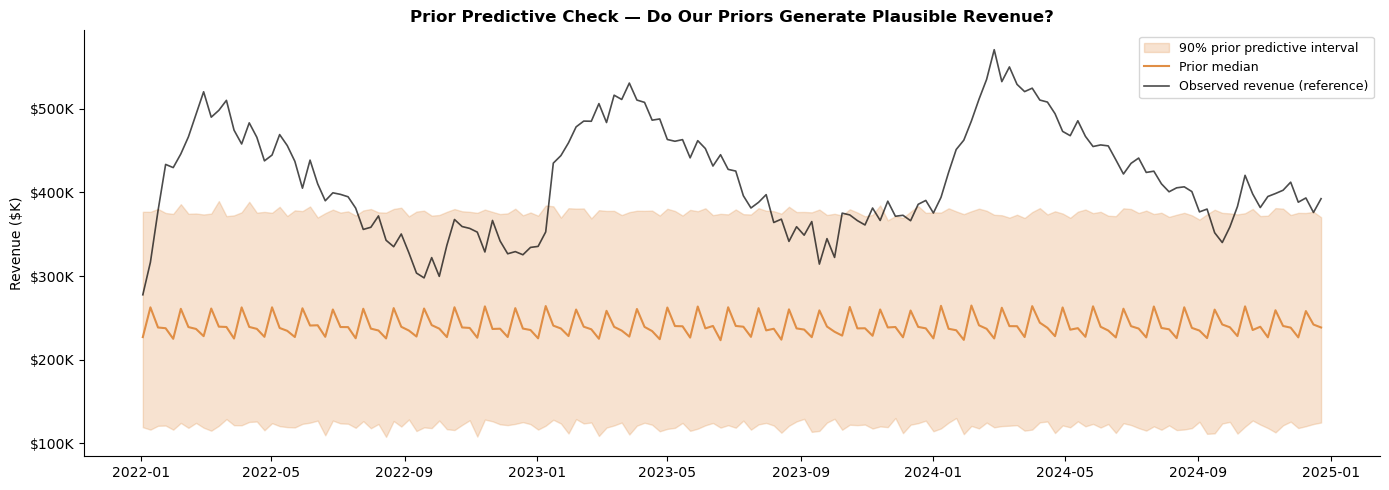

Prior predictive revenue summary (weekly, $K):
  5th  percentile : $120.8K
  Median          : $239.6K
  95th percentile : $377.0K
  Fraction negative: 0.0%

Observed revenue range: $277.6K – $570.7K

✅ Good if: prior range loosely brackets observed range, median in ballpark
⚠️  Bad if: mostly negative, or 95th pct > $5M, or median < $100K


In [5]:
# ── Cell 3a: Prior Predictive Check ──────────────────────────────────────────
#
# WHAT THIS IS:
#   Sample from the priors WITHOUT conditioning on any data.
#   We're asking: "Given only what we believe before seeing the data,
#   does the model generate plausible weekly revenue numbers?"
#
# WHY WE DO THIS:
#   Priors that are too wide generate nonsense (negative revenue, $500M weeks).
#   Priors that are too tight will prevent the data from moving the posterior.
#   This check catches both problems BEFORE we waste compute on a broken model.
#
# WHAT WE'RE LOOKING FOR:
#   - Revenue range should be roughly $0 – $3M per week (plausible for Arclight)
#   - Median prior predictive should be in the right ballpark (~$500K–$1M)
#   - No catastrophic values (negative, or orders of magnitude off)
#   - Wide uncertainty is fine and expected — we haven't seen data yet
#
# If revenue is mostly negative or hitting $50M+, priors need adjustment
# before we touch the sampler.

from pymc_extras.prior import Prior
import numpy as np

# ── Prior spec (same as Cell 3 — keep in sync) ───────────────────────────────
k_centers = np.array([33_000, 31_000, 3_000, 17_000, 97_000])
n_centers  = np.array([3.0, 1.8, 2.2, 2.0, 1.5])
k_sigma    = k_centers * 0.20
n_sigma    = np.full(5, 0.5)

saturation_beta_sigma = np.array([
    80_000,    # Paid Search — doubled
    80_000,    # Social — doubled
    40_000,    # Email — doubled
    50_000,    # Display — doubled
    120_000,   # TV — doubled
])

model_config_ppc = {
    "intercept":        Prior("Normal",     mu=250_000, sigma=75_000),
    "saturation_beta":  Prior("HalfNormal", sigma=saturation_beta_sigma),
    "saturation_kappa": Prior("Normal",     mu=k_centers, sigma=k_sigma),
    "saturation_slope": Prior("Normal",     mu=n_centers, sigma=n_sigma),
    "gamma_fourier":    Prior("Laplace",    mu=0, b=0.1),
    "likelihood":       Prior("Normal",     sigma=Prior("HalfNormal", sigma=20_000)),
}

mmm_ppc = MMM(
    channel_columns=CHANNELS,
    date_column="week",
    adstock=GeometricAdstock(l_max=8),
    saturation=HillSaturation(),
    yearly_seasonality=2,
    model_config=model_config_ppc,
)

X = df[["week"] + CHANNELS].copy()
y = df["revenue"].copy()

# Sample priors only — no data conditioning
prior_idata = mmm_ppc.sample_prior_predictive(X, random_seed=42)

# ── Plot ──────────────────────────────────────────────────────────────────────
# Pull prior predictive revenue samples
# Shape: (chains, draws, weeks) — flatten chains/draws
# sample_prior_predictive returns InferenceData in some pymc-marketing versions
# and a bare xarray.Dataset in others — handle both.
ppc_ds = getattr(prior_idata, "prior_predictive", prior_idata)
prior_y = ppc_ds["y"].values
prior_y_flat = prior_y.reshape(-1, len(df))  # (samples, weeks)

lo  = np.percentile(prior_y_flat,  5, axis=0)
mid = np.percentile(prior_y_flat, 50, axis=0)
hi  = np.percentile(prior_y_flat, 95, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df.week, lo / 1e3, hi / 1e3,
                alpha=0.25, color="#E08E45",
                label="90% prior predictive interval")
ax.plot(df.week, mid / 1e3,
        color="#E08E45", lw=1.5, label="Prior median")
ax.plot(df.week, df.revenue / 1e3,
        color="black", lw=1.2, alpha=0.7, label="Observed revenue (reference)")

ax.set_ylabel("Revenue ($K)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.set_title("Prior Predictive Check — Do Our Priors Generate Plausible Revenue?",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("11a_prior_predictive_check.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print("Prior predictive revenue summary (weekly, $K):")
print(f"  5th  percentile : ${np.percentile(prior_y_flat,  5) / 1e3:,.1f}K")
print(f"  Median          : ${np.percentile(prior_y_flat, 50) / 1e3:,.1f}K")
print(f"  95th percentile : ${np.percentile(prior_y_flat, 95) / 1e3:,.1f}K")
print(f"  Fraction negative: {(prior_y_flat < 0).mean():.1%}")
print(f"\nObserved revenue range: "
      f"${df.revenue.min()/1e3:,.1f}K – ${df.revenue.max()/1e3:,.1f}K")
print("\n✅ Good if: prior range loosely brackets observed range, median in ballpark")
print("⚠️  Bad if: mostly negative, or 95th pct > $5M, or median < $100K")

In [6]:
# ── Cell 3b: Smoke Test (2 chains × 500 draws) ───────────────────────────────
#
# WHAT THIS IS:
#   A cheap fast fit using the same model spec — 2 chains, 500 draws.
#   Takes ~2–3 minutes instead of 9+. We're not using these results;
#   we're using the R-hat values to ask: "Is the sampler going to converge
#   before we commit to the full expensive run?"
#
# WHY WE DO THIS:
#   If R-hat is 4.0 on a smoke test, it'll be 4.0 on the full run too.
#   Catch failure here, fix priors, re-smoke-test — iterate cheaply.
#   Only run the full fit once R-hat is trending toward 1.0 here.
#
# WHAT WE'RE LOOKING FOR:
#   R-hat < 1.2 on all parameters = green light for full fit
#   R-hat 1.2–1.5 = yellow, investigate before proceeding
#   R-hat > 1.5  = red, stop and fix priors first
#
# NOTE: ESS will be low by design (we only have 1000 total draws).
#   Ignore ESS here — it's not meaningful at this sample size.
#   R-hat is the only signal we care about in the smoke test.

diag_vars = [
    "intercept", "adstock_alpha", "saturation_beta",
    "saturation_kappa", "saturation_slope", "y_sigma"
]

mmm_smoke = MMM(
    channel_columns=CHANNELS,
    date_column="week",
    adstock=GeometricAdstock(l_max=8),
    saturation=HillSaturation(),
    yearly_seasonality=2,
    model_config=model_config_ppc,   # same config as Cell 3a
)

idata_smoke = mmm_smoke.fit(
    X, y,
    target_accept=0.92,
    draws=500,
    tune=1000,         # tune longer relative to draws — helps with tricky posteriors
    chains=2,
    random_seed=42,
    initvals={"intercept": 150_000},
)

smoke_summary = az.summary(idata_smoke, var_names=diag_vars, round_to=3)
print("Smoke test R-hat values:")
print(smoke_summary[["mean", "r_hat", "ess_bulk"]].to_string())

# Traffic light
max_rhat = smoke_summary["r_hat"].max()
print(f"\nMax R-hat: {max_rhat:.3f}")
if max_rhat < 1.2:
    print("✅ Green light — proceed to full fit")
elif max_rhat < 1.5:
    print("⚠️  Yellow — investigate which parameters are struggling before full fit")
else:
    print("🔴 Red — do not run full fit, priors need more work")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, adstock_alpha, saturation_slope, saturation_kappa, saturation_beta, gamma_fourier, y_sigma]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 139 seconds.
There were 948 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Smoke test R-hat values:
                                           mean  r_hat  ess_bulk
intercept                             75000.347  2.278     2.583
adstock_alpha[spend_paid_search]          0.251  2.236    75.097
adstock_alpha[spend_social]               0.359  2.260     5.939
adstock_alpha[spend_email]                0.315  2.239    62.618
adstock_alpha[spend_display]              0.549  2.304     4.050
adstock_alpha[spend_tv]                   0.474  2.240     2.643
saturation_beta[spend_paid_search]    58582.212  2.250    32.708
saturation_beta[spend_social]         94924.564  2.233     3.770
saturation_beta[spend_email]          41477.708  2.289     8.478
saturation_beta[spend_display]        32748.856  2.234   101.127
saturation_beta[spend_tv]            137684.830  2.234     2.647
saturation_kappa[spend_paid_search]   32770.028  2.260    83.911
saturation_kappa[spend_social]        31707.899  2.298    30.100
saturation_kappa[spend_email]          3019.200  2.232    82.883


In [7]:
help(GeometricAdstock)

Help on class GeometricAdstock in module pymc_marketing.mmm.components.adstock:

class GeometricAdstock(AdstockTransformation)
 |  GeometricAdstock(l_max: 'int' = FieldInfo(annotation=NoneType, required=True, description='Maximum lag for the adstock transformation.', metadata=[Gt(gt=0)]), normalize: 'bool' = FieldInfo(annotation=NoneType, required=False, default=True, description='Whether to normalize the adstock values.'), mode: 'ConvMode' = FieldInfo(annotation=NoneType, required=False, default=<ConvMode.After: 'After'>, description='Convolution mode.'), priors: 'dict[str, SupportedPrior] | None' = FieldInfo(annotation=NoneType, required=False, default=None, description='Priors for the parameters.'), prefix: 'str | None' = FieldInfo(annotation=NoneType, required=False, default=None, description='Prefix for the parameters.')) -> 'None'
 |  
 |  Wrapper around geometric adstock function.
 |  
 |  For more information, see :func:`pymc_marketing.mmm.transformers.geometric_adstock`.
 |  


In [8]:
# Scratch: does MMM accept a list for adstock?
import inspect
print(inspect.signature(MMM.__init__))

(self, date_column: str = FieldInfo(annotation=NoneType, required=True, description='Column name of the date variable.'), channel_columns: list[str] = FieldInfo(annotation=NoneType, required=True, description='Column names of the media channel variables.', metadata=[MinLen(min_length=1)]), adstock: typing.Annotated[pymc_marketing.mmm.components.adstock.AdstockTransformation, InstanceOf()] = FieldInfo(annotation=NoneType, required=True, description='Type of adstock transformation to apply.'), saturation: typing.Annotated[pymc_marketing.mmm.components.saturation.SaturationTransformation, InstanceOf()] = FieldInfo(annotation=NoneType, required=True, description='Type of saturation transformation to apply.'), time_varying_intercept: bool = FieldInfo(annotation=NoneType, required=False, default=False, description='Whether to consider time-varying intercept.'), time_varying_media: bool = FieldInfo(annotation=NoneType, required=False, default=False, description='Whether to consider time-varyi

In [9]:
# Scratch: can we set per-channel adstock alpha via model_config?
mmm_test = MMM(
    channel_columns=CHANNELS,
    date_column="week",
    adstock=GeometricAdstock(l_max=8),
    saturation=HillSaturation(),
    yearly_seasonality=2,
)
print(mmm_test.model_config.keys())

dict_keys(['intercept', 'likelihood', 'gamma_control', 'gamma_fourier', 'adstock_alpha', 'saturation_slope', 'saturation_kappa', 'saturation_beta'])


In [10]:
# ── Cell 3: PyMC-Marketing Model Spec (v0.17.1) ───────────────────────────────
#
# In v0.17.1, channel priors are set via model_config using the Prior class
# from pymc_extras.prior
#
#   Key parameters:
#   saturation_beta : per-channel revenue coefficient, one sigma per channel
#                     via a numpy array (channels must match CHANNELS order)
#   intercept       : baseline (zero-marketing) revenue
#   likelihood      : observation noise
#
# Note: per-channel adstock decay priors are not independently settable in
# v0.17.1 via model_config, instead a shared GeometricAdstock instance is used.
# We set its alpha prior to reflect a moderate decay center across channels.
# The data will pull individual channel estimates toward their true values.

from pymc_extras.prior import Prior
import numpy as np

# Empirical k values (half-saturation points in raw $ from transform cell)
# These become the centers of tight Normal priors
k_centers = np.array([
    33_000,   # Paid Search
    31_000,   # Social
     3_000,   # Email
    17_000,   # Display
    97_000,   # TV
])

# Empirical n values (Hill slope) from transform cell
n_centers = np.array([3.0, 1.8, 2.2, 2.0, 1.5])  # PS, Social, Email, Display, TV

# k sigma: ~20% of center — wide enough to learn, tight enough to anchor
k_sigma = k_centers * 0.20

# n sigma: 0.5 — lets the data move n by ~1 unit in either direction
n_sigma = np.array([0.5, 0.5, 0.5, 0.5, 0.5])

# saturation_beta sigma per channel which reflects our prior on max revenue
# contribution at full saturation, ordered to match CHANNELS.
# Paid Search / Social / TV get wider sigmas (larger absolute effects possible).
# Email / Display get tighter sigmas (lower spend = lower ceiling).
saturation_beta_sigma = np.array([
    40_000, # old -> 60_000,   # Paid Search
    40_000, # old -> 55_000,   # Social
    20_000, # old -> 30_000,   # Email
    25_000, # old -> 40_000,   # Display
    60_000, # old -> 80_000,   # TV
])

model_config = {
    # Zero-marketing weekly revenue floor — centered on our EDA naive baseline
    "intercept": Prior("Normal", mu=350_000, sigma=30_000), # old -> sigma=50_000

    # Per-channel revenue coefficient — HalfNormal forces positive ROAS
    "saturation_beta": Prior("HalfNormal", sigma=saturation_beta_sigma),

    "saturation_kappa": Prior("Normal", mu=k_centers, sigma=k_sigma),

    "saturation_slope": Prior("Normal", mu=n_centers, sigma=n_sigma),

    # Fourier seasonality coefficients — small Laplace prior (sparse/regularizing)
    "gamma_fourier": Prior("Laplace", mu=0, b=0.1),

    # Observation noise
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=20_000)),
}

mmm = MMM(
    channel_columns=CHANNELS,
    date_column="week",
    adstock=GeometricAdstock(l_max=8),   # shared adstock; decay sampled internally
    saturation=HillSaturation(),         # Hill saturation; k & slope sampled internally
    yearly_seasonality=2,
    model_config=model_config,
)

print("Model spec ready.")
print(f"  Channels          : {CHANNELS}")
print(f"  Adstock           : GeometricAdstock(l_max=8)")
print(f"  Saturation        : HillSaturation")
print(f"  Yearly seasonality: K=2 Fourier (pymc-marketing internal)")
print(f"\n  saturation_beta sigmas:")
for label, s in zip(LABELS, saturation_beta_sigma):
    print(f"    {label:<14} ${s:,.0f}")


print("Model spec ready — tightened priors.")
print(f"\n  k centers (half-saturation):  {dict(zip(LABELS, k_centers))}")
print(f"  k sigma   (20% of center):    {dict(zip(LABELS, k_sigma.astype(int)))}")
print(f"  n centers (Hill slope):        {dict(zip(LABELS, n_centers))}")
print(f"  n sigma:                       {dict(zip(LABELS, n_sigma))}")

Model spec ready.
  Channels          : ['spend_paid_search', 'spend_social', 'spend_email', 'spend_display', 'spend_tv']
  Adstock           : GeometricAdstock(l_max=8)
  Saturation        : HillSaturation
  Yearly seasonality: K=2 Fourier (pymc-marketing internal)

  saturation_beta sigmas:
    Paid Search    $40,000
    Social         $40,000
    Email          $20,000
    Display        $25,000
    TV             $60,000
Model spec ready — tightened priors.

  k centers (half-saturation):  {'Paid Search': np.int64(33000), 'Social': np.int64(31000), 'Email': np.int64(3000), 'Display': np.int64(17000), 'TV': np.int64(97000)}
  k sigma   (20% of center):    {'Paid Search': np.int64(6600), 'Social': np.int64(6200), 'Email': np.int64(600), 'Display': np.int64(3400), 'TV': np.int64(19400)}
  n centers (Hill slope):        {'Paid Search': np.float64(3.0), 'Social': np.float64(1.8), 'Email': np.float64(2.2), 'Display': np.float64(2.0), 'TV': np.float64(1.5)}
  n sigma:                     

***
**Notes:**
***
***

In [11]:
# ── Cell 4: Fit the Model ─────────────────────────────────────────────────────
X = df[["week"] + CHANNELS].copy()
y = df["revenue"].copy()

idata = mmm.fit(
    X, y,
    target_accept=0.9,
    draws=1000,
    tune=1000,
    chains=4,
    random_seed=42,
)

print("\nSampling complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, adstock_alpha, saturation_slope, saturation_kappa, saturation_beta, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 338 seconds.
There were 3563 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()


Sampling complete.


In [12]:
# Check what variable names are actually in the posterior
print("\nPosterior variable names:")
print(list(idata.posterior.data_vars))


Posterior variable names:
['intercept', 'adstock_alpha', 'saturation_slope', 'saturation_kappa', 'saturation_beta', 'gamma_fourier', 'y_sigma', 'channel_contribution', 'total_contribution', 'fourier_contribution', 'yearly_seasonality_contribution', 'mu', 'channel_contribution_original_scale', 'total_contribution_original_scale', 'yearly_seasonality_contribution_original_scale', 'y_original_scale']


***
**Notes:**
Double check the names of the posterior variables for use in diagnostics & results!
***
***

In [13]:
# ── Cell 5: Sampling Diagnostics ─────────────────────────────────────────────
# Two things we must check before trusting any results:
#   R-hat  : chain convergence — should be < 1.01 for all parameters
#   ESS    : effective sample size — should be > 400 (we have 4000 draws total)
# If either fails, results are unreliable regardless of how good the fit looks.

diag_vars = [
    "intercept", "adstock_alpha", "saturation_beta",
    "saturation_kappa", "saturation_slope", "y_sigma"
]

summary = az.summary(idata, var_names=diag_vars, round_to=3)
print("\nDiagnostic summary:")
print(summary[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"]].to_string())

# Flag any convergence issues
rhat_vals = summary["r_hat"]
bad_rhat = rhat_vals[rhat_vals > 1.01]
bad_ess  = summary["ess_bulk"][summary["ess_bulk"] < 400]

print("\n--- Convergence check ---")
if bad_rhat.empty:
    print("✅ All R-hat < 1.01 — chains converged")
else:
    print(f"⚠️  R-hat > 1.01: {bad_rhat.to_dict()}")

print("\n--- ESS check ---")
if bad_ess.empty:
    print("✅ All ESS > 400 — sufficient effective samples")
else:
    print(f"⚠️  Low ESS: {bad_ess.to_dict()}")


Diagnostic summary:
                                          mean          sd     hdi_3%     hdi_97%  r_hat  ess_bulk
intercept                            87500.436  151573.245      0.475  350000.178  1.637     6.811
adstock_alpha[spend_paid_search]         0.235       0.159      0.000       0.537  1.528   570.372
adstock_alpha[spend_social]              0.489       0.151      0.284       0.704  1.581     6.893
adstock_alpha[spend_email]               0.318       0.195      0.002       0.688  1.546    99.435
adstock_alpha[spend_display]             0.495       0.248      0.070       0.894  1.315    15.269
adstock_alpha[spend_tv]                  0.611       0.215      0.245       0.793  1.655     6.477
saturation_beta[spend_paid_search]   28954.487   21115.078      9.126   66842.846  1.535   337.684
saturation_beta[spend_social]        30469.958   28618.938    526.526   70709.320  1.421     8.561
saturation_beta[spend_email]         18353.424   11516.391     52.910   34717.183  1.094

***
**Notes:**
Initial Resutls -> Every single parameter had R-hat > 4 and ESS = 4, essentially the results were meaningless. R-hat needs to be <=1 & ESS > 400.

Why did my initial model fail? 
***
***

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


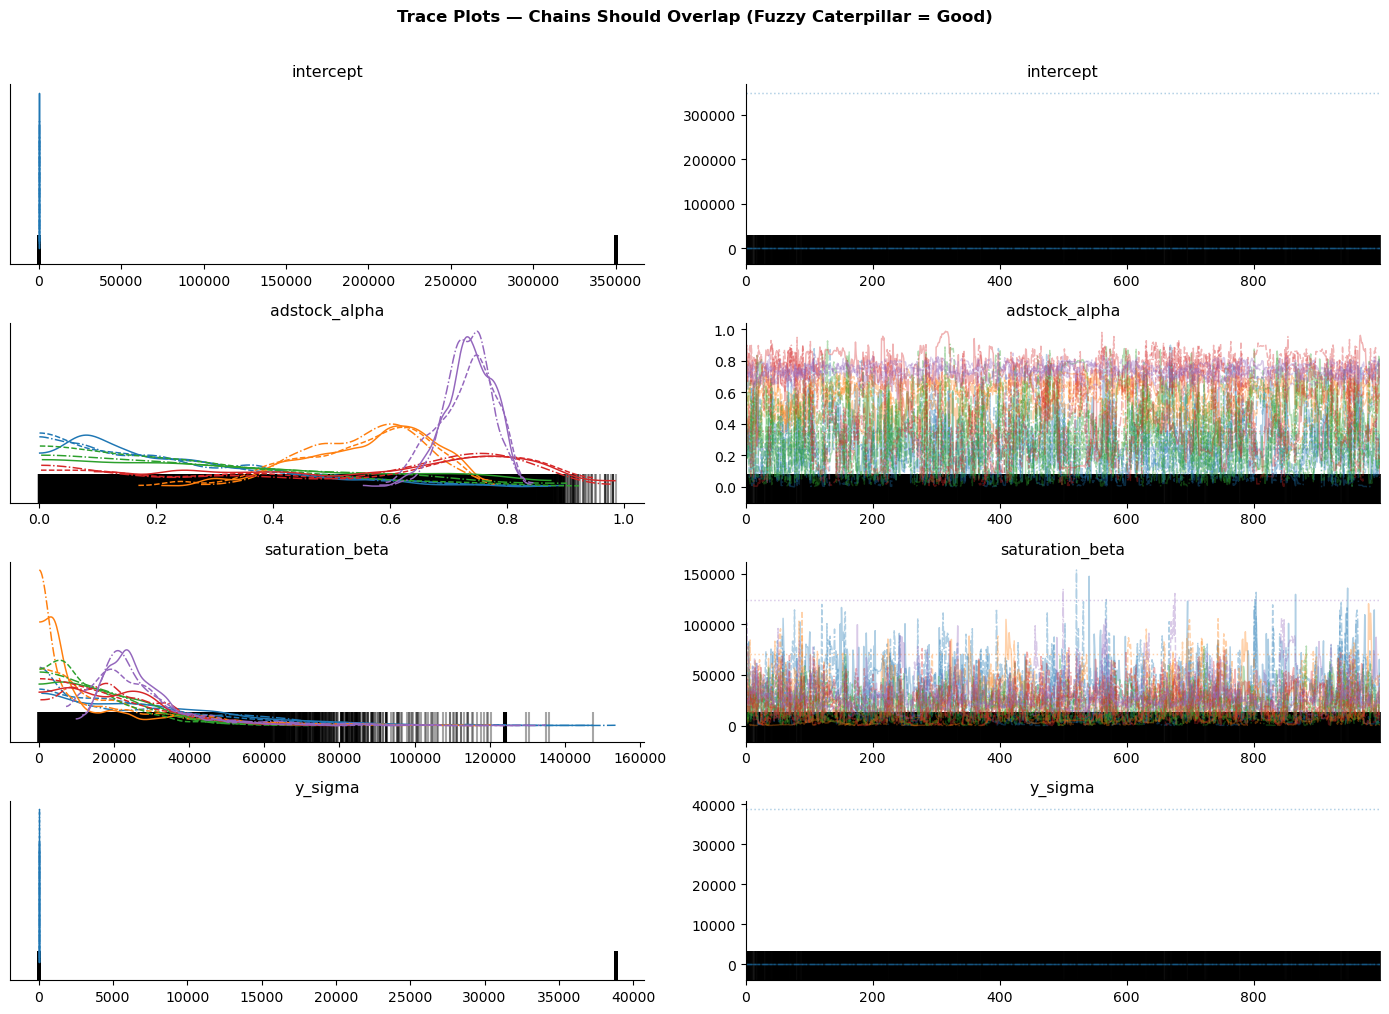

In [14]:
# ── Cell 6: Trace Plots (Visual Convergence Check) ───────────────────────────
# Four chains should overlap like fuzzy caterpillars — distinct bands = problem.
az.plot_trace(
    idata,
    var_names=["intercept", "adstock_alpha", "saturation_beta", "y_sigma"],
    compact=True,
    figsize=(14, 10),
)
plt.suptitle("Trace Plots — Chains Should Overlap (Fuzzy Caterpillar = Good)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("12_trace_plots.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:**
Double check the names of the posterior variables for use in diagnostics & results!
***
***

Sampling: [y]


Output()

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\pymc_marketing\mmm\mmm.py:2411: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


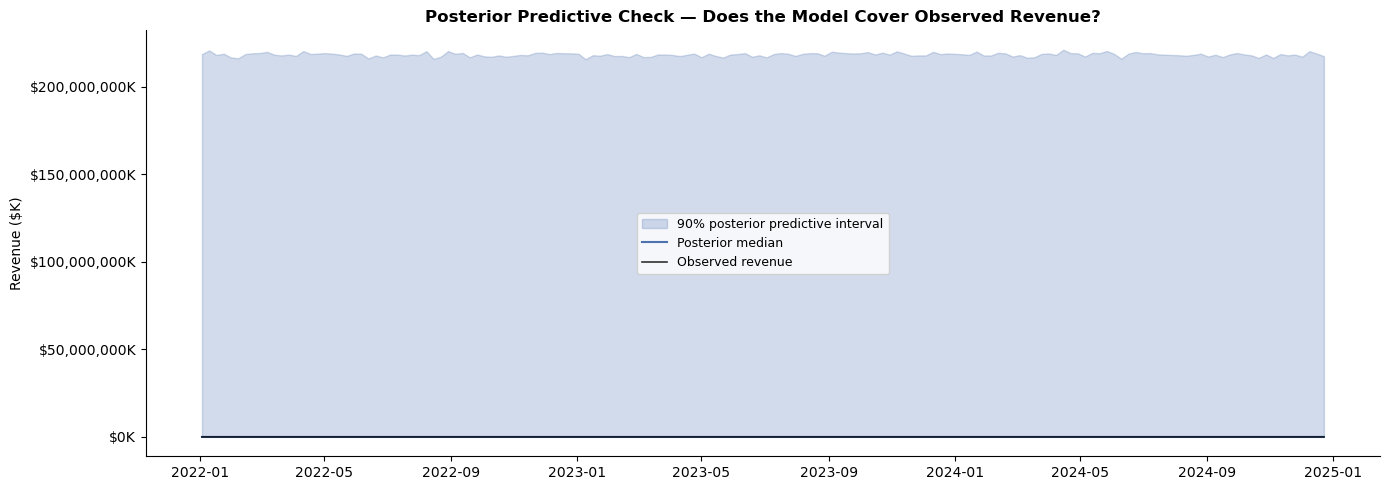


Observed coverage within 90% PI: 95.5%  (expect ~90%)


In [15]:
# ── Cell 7: Posterior Predictive Check ───────────────────────────────────────
# Does the model's predicted revenue distribution actually cover the observed data?
# If the posterior predictive is systematically off, the model is misspecified.

mmm.sample_posterior_predictive(X, extend_idata=True, random_seed=42)

fig, ax = plt.subplots(figsize=(14, 5))

# Posterior predictive samples (y (y_original_units) is in $ units)
ppc = idata.posterior_predictive["y"].values
ppc_flat = ppc.reshape(-1, len(df))  # (chains*draws, weeks)

lo  = np.percentile(ppc_flat, 5,  axis=0)
mid = np.percentile(ppc_flat, 50, axis=0)
hi  = np.percentile(ppc_flat, 95, axis=0)

ax.fill_between(df.week, lo / 1e3, hi / 1e3,
                alpha=0.25, color="#4C72B0", label="90% posterior predictive interval")
ax.plot(df.week, mid / 1e3, color="#4C72B0", lw=1.5, label="Posterior median")
ax.plot(df.week, df.revenue / 1e3, color="black", lw=1.2, alpha=0.8, label="Observed revenue")

ax.set_ylabel("Revenue ($K)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.set_title("Posterior Predictive Check — Does the Model Cover Observed Revenue?",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("13_posterior_predictive.png", dpi=150, bbox_inches="tight")
plt.show()

# Coverage stat
coverage = np.mean((df.revenue.values >= lo) & (df.revenue.values <= hi))
print(f"\nObserved coverage within 90% PI: {coverage:.1%}  (expect ~90%)")

***
**Notes:**
Double check the names of the posterior variables for use in diagnostics & results!
***
***